In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from libpysal.weights import KNN
from esda.moran import Moran

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

df = pd.read_csv("../outputs/soil_clusters_top_3_models.csv")
FEATURES = ["taw", "organic_carbon", "cec", "ph", "sand_pct"]
CLUSTER_MODELS = {
    "K-Means": "cluster_kmeans",
    "Agglomerative": "cluster_agg",
    "GMM": "cluster_gmm"
}

### **Figure 1: Validation metrics for all 4 algorithms**

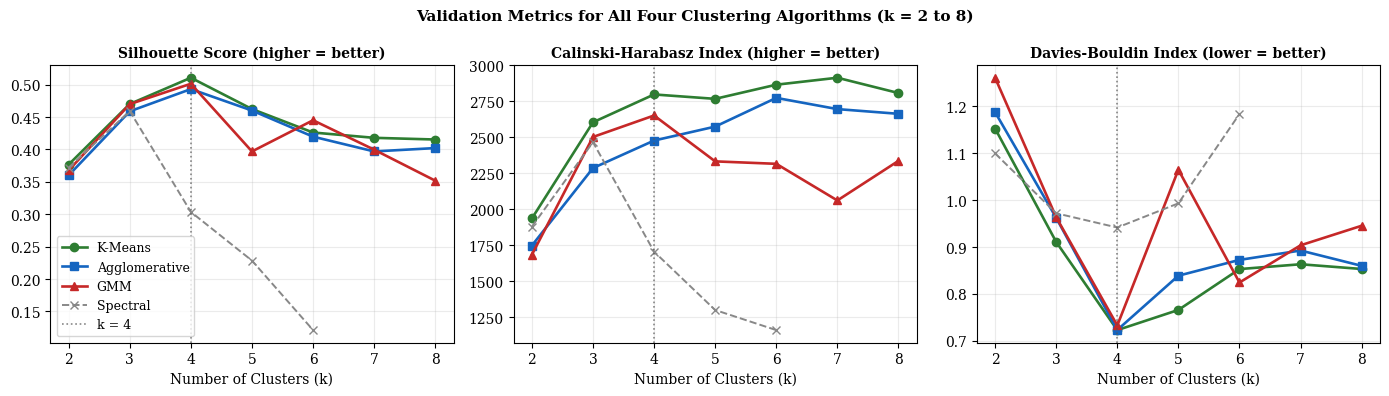

In [3]:
k_all  = [2, 3, 4, 5, 6, 7, 8]
k_spec = [2, 3, 4, 5, 6]

metrics = {
    "K-Means": {
        "sil": [0.3767, 0.4701, 0.5106, 0.4623, 0.4261, 0.4179, 0.4153],
        "ch":  [1934.8, 2602.9, 2796.3, 2765.7, 2864.0, 2912.4, 2806.1],
        "db":  [1.1527, 0.9109, 0.7229, 0.7659, 0.8530, 0.8633, 0.8532],
    },
    "Agglomerative": {
        "sil": [0.3601, 0.4588, 0.4931, 0.4600, 0.4197, 0.3969, 0.4021],
        "ch":  [1746.6, 2285.0, 2476.1, 2572.9, 2772.4, 2694.5, 2661.8],
        "db":  [1.1876, 0.9623, 0.7232, 0.8389, 0.8726, 0.8926, 0.8599],
    },
    "GMM": {
        "sil": [0.3677, 0.4699, 0.5013, 0.3969, 0.4450, 0.3996, 0.3518],
        "ch":  [1682.8, 2500.9, 2650.1, 2331.4, 2314.4, 2060.0, 2334.9],
        "db":  [1.2610, 0.9636, 0.7328, 1.0648, 0.8244, 0.9037, 0.9454],
    },
    "Spectral": {
        "sil": [0.3719, 0.4591, 0.3036, 0.2285, 0.1213],
        "ch":  [1877.8, 2464.7, 1704.3, 1298.9, 1159.4],
        "db":  [1.0996, 0.9720, 0.9416, 0.9932, 1.1837],
    },
}

styles = {
    "K-Means":       ("o", "#2e7d32", "-",  1.9),
    "Agglomerative": ("s", "#1565c0", "-",  1.9),
    "GMM":           ("^", "#c62828", "-",  1.9),
    "Spectral":      ("x", "#888888", "--", 1.4),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = [
    ("sil", "Silhouette Score (higher = better)"),
    ("ch",  "Calinski-Harabasz Index (higher = better)"),
    ("db",  "Davies-Bouldin Index (lower = better)"),
]

for ax, (key, title) in zip(axes, titles):
    for name, vals in metrics.items():
        mk, col, ls, lw = styles[name]
        k = k_spec if name == "Spectral" else k_all
        ax.plot(k, vals[key], marker=mk, color=col, linestyle=ls,
                linewidth=lw, label=name, markersize=6)
    ax.axvline(4, color="#555", linestyle=":", linewidth=1.2, alpha=0.7, label="k = 4")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Number of Clusters (k)")
    ax.set_xticks([2, 3, 4, 5, 6, 7, 8])
    ax.grid(True, alpha=0.25)

axes[0].legend(fontsize=9)
fig.suptitle("Validation Metrics for All Four Clustering Algorithms (k = 2 to 8)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/fig1_validation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### **Figure 2: Cluster size distribution (top 3 models)**

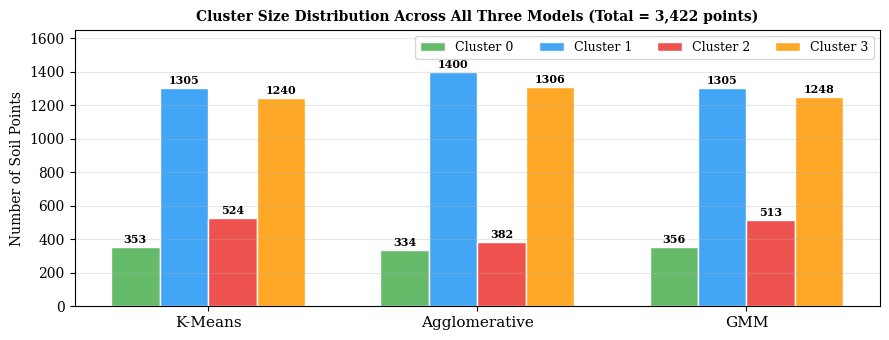

In [4]:
sizes = {
    "K-Means":       [353,  1305, 524,  1240],
    "Agglomerative": [334,  1400, 382,  1306],
    "GMM":           [356,  1305, 513,  1248],
}
zone_colors = ["#66bb6a", "#42a5f5", "#ef5350", "#ffa726"]
models = list(sizes.keys())

fig, ax = plt.subplots(figsize=(9, 3.5))
x = np.arange(3)
w = 0.18

for i, (zone, col) in enumerate(zip(["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"], zone_colors)):
    vals = [sizes[m][i] for m in models]
    bars = ax.bar(x + (i - 1.5) * w, vals, w, label=zone, color=col, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 12,
                str(v), ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Number of Soil Points")
ax.set_ylim(0, 1650)
ax.set_title("Cluster Size Distribution Across All Three Models (Total = 3,422 points)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9, ncol=4)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/fig2_cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

### **Figure 3: Cluster characteristics heatmap**

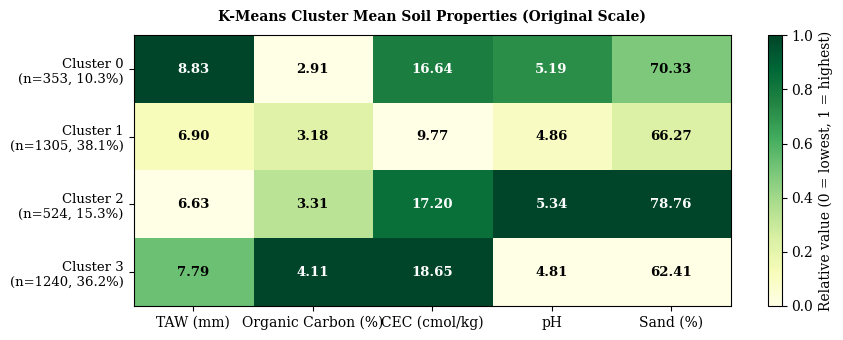

In [5]:
features  = ["TAW (mm)", "Organic Carbon (%)", "CEC (cmol/kg)", "pH", "Sand (%)"]
clusters  = ["Cluster 0\n(n=353, 10.3%)", "Cluster 1\n(n=1305, 38.1%)",
             "Cluster 2\n(n=524, 15.3%)",  "Cluster 3\n(n=1240, 36.2%)"]
values = np.array([
    [8.83, 2.91, 16.64, 5.19, 70.33],
    [6.90, 3.18,  9.77, 4.86, 66.27],
    [6.63, 3.31, 17.20, 5.34, 78.76],
    [7.79, 4.11, 18.65, 4.81, 62.41],
])

norm = (values - values.min(axis=0)) / (values.max(axis=0) - values.min(axis=0) + 1e-9)

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(norm, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(features, fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(clusters, fontsize=9.5)

for i in range(4):
    for j in range(5):
        ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center",
                fontsize=9.5, fontweight="bold",
                color="white" if norm[i, j] > 0.65 else "black")

ax.set_title("K-Means Cluster Mean Soil Properties (Original Scale)",
             fontsize=10, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, label="Relative value (0 = lowest, 1 = highest)")
plt.tight_layout()
plt.savefig("../outputs/fig3_cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### **Figure 4: Inter-model agreement**

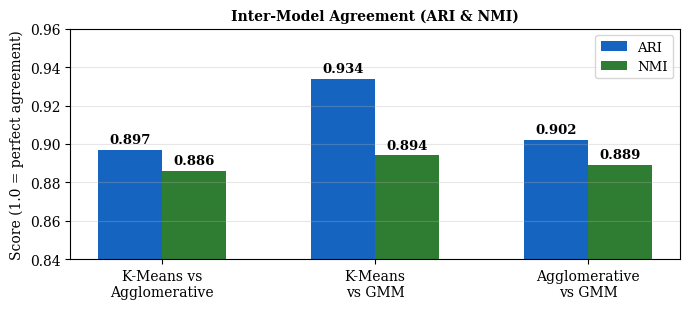

In [7]:
pairs    = ["K-Means vs\nAgglomerative", "K-Means\nvs GMM", "Agglomerative\nvs GMM"]
ari_vals = [0.897, 0.934, 0.902]
nmi_vals = [0.886, 0.894, 0.889]

fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(3)
w = 0.3
b1 = ax.bar(x - w/2, ari_vals, w, label="ARI", color="#1565c0")
b2 = ax.bar(x + w/2, nmi_vals, w, label="NMI", color="#2e7d32")

for bar, v in zip(list(b1) + list(b2), ari_vals + nmi_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(pairs, fontsize=10)
ax.set_ylim(0.84, 0.96)
ax.set_ylabel("Score (1.0 = perfect agreement)")
ax.set_title("Inter-Model Agreement (ARI & NMI)", fontsize=10, fontweight="bold")
ax.legend(fontsize=9.5)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/fig4_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

### **Figure 5: Surrogate model fidelity**

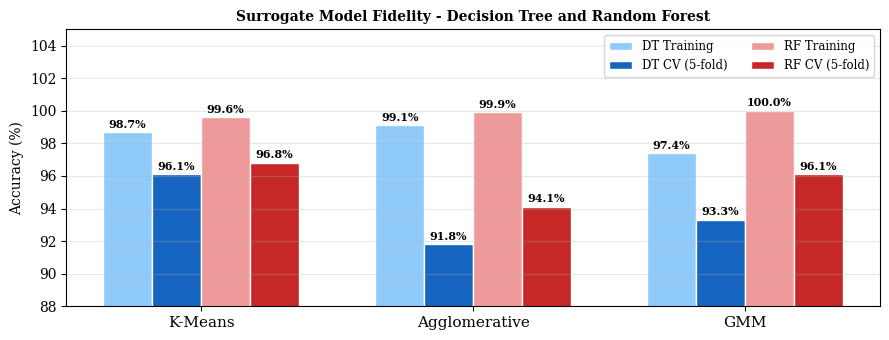

In [9]:
model_names = ["K-Means", "Agglomerative", "GMM"]
dt_train = [98.7, 99.1, 97.4]
dt_cv    = [96.1, 91.8, 93.3]
rf_train = [99.6, 99.9, 100.0]
rf_cv    = [96.8, 94.1, 96.1]

fig, ax = plt.subplots(figsize=(9, 3.5))
x = np.arange(3)
w = 0.18
b1 = ax.bar(x - 1.5*w, dt_train, w, label="DT Training",   color="#90caf9", edgecolor="white")
b2 = ax.bar(x - 0.5*w, dt_cv,    w, label="DT CV (5-fold)", color="#1565c0", edgecolor="white")
b3 = ax.bar(x + 0.5*w, rf_train, w, label="RF Training",   color="#ef9a9a", edgecolor="white")
b4 = ax.bar(x + 1.5*w, rf_cv,    w, label="RF CV (5-fold)", color="#c62828", edgecolor="white")

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                f"{bar.get_height():.1f}%", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(88, 105)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Surrogate Model Fidelity - Decision Tree and Random Forest",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8.5, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/fig5_surrogate.png", dpi=150, bbox_inches="tight")
plt.show()

### **Figure 6: Moran's I**

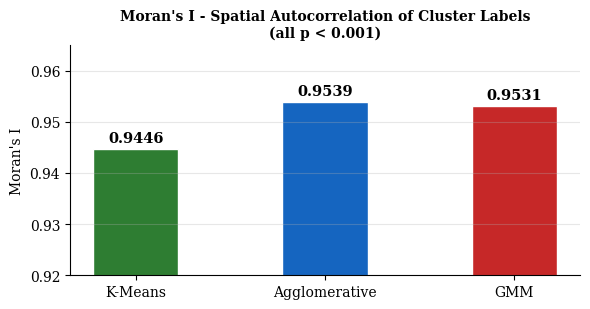

In [10]:
model_names = ["K-Means", "Agglomerative", "GMM"]
morans_vals = [0.9446, 0.9539, 0.9531]
colors      = ["#2e7d32", "#1565c0", "#c62828"]

fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.bar(model_names, morans_vals, color=colors, edgecolor="white", width=0.45)

for bar, v in zip(bars, morans_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0008,
            f"{v:.4f}", ha="center", va="bottom", fontsize=10.5, fontweight="bold")

ax.set_ylim(0.92, 0.965)
ax.set_ylabel("Moran's I")
ax.set_title("Moran's I - Spatial Autocorrelation of Cluster Labels\n(all p < 0.001)",
             fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/fig6_morans.png", dpi=150, bbox_inches="tight")
plt.show()